# Analyse de la Gouvernance Économique du Bénin (2021-2026)
## Dashboard GDELT Events + IDE Projects - Hackathon iSHEERO × DataCamp

---

## 📋 PROBLÉMATIQUE

Le Bénin s'apprête à vivre une transition présidentielle majeure (mai 2026). Le nouveau gouvernement doit comprendre :

1. **Comment le monde perçoit l'économie du Bénin** et cette perception a-t-elle changé sous Talon ?
2. **Les perceptions médiatiques influencent-elles réellement les investissements directs étrangers (IDE) ?**
3. **Quels secteurs reçoivent le plus d'attention médiatique et lesquels manquent de reconnaissance ?**
4. **Y a-t-il un fossé entre le "hype médiatique" et les résultats réels des projets ?** (surpromesse vs sous-livraison)
5. **Comment l'attention médiatique d'un projet affecte son succès réel ?**
6. **Comment le Bénin se positionne-t-il par rapport à la région en termes de narratif économique ?**

---

## 🎯 OBJECTIF

Construire un **dashboard d'intelligence économique** capable de :

- ✅ Mesurer la **perception internationale** du Bénin via l'analyse de tone GDELT (2021-2026)
- ✅ Corréler cette perception avec les **flux d'investissements réels** (IDE du World Bank)
- ✅ Identifier les **secteurs stratégiques** les mieux/moins couverts médiatiquement
- ✅ Détecter les **secteurs overhyped** (beaucoup de couverture, peu de résultats)
- ✅ Analyser l'impact de la **médiatisation sur les résultats de projets**
- ✅ Benchmarker le **positionnement du Bénin** par rapport à la région (Niger, Nigeria, Togo)

**Output attendu** : Un notebook reproductible générant les visualisations + insights pour un pitch de 10 minutes au jury (Demo Day 9 mai 2026).

---

## 📊 DONNÉES UTILISÉES

| Source | Dataset | Timeframe | Granularité |
|--------|---------|-----------|-------------|
| **GDELT** | `events_2021_2026_cleaned.csv` |  2021 -  2026 | Par jour/article |
| **World Bank** | `Project_List_Cleaned.csv` | 2021-2026 | 21 projets (IDE/IDA/Grants) |
| **Secteurs** | Colonne `Secteur` (Project_List) | 2021-2026 | 10 secteurs définis |

---

In [1]:
# ============================================================================
# 1. IMPORTS & SETUP
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

print("✅ Imports completed")

✅ Imports completed


In [3]:
# ============================================================================
# 2. CHARGEMENT DES DONNÉES
# ============================================================================

# Charger les datasets
events_df = pd.read_csv('../data/processed/events_2021_2026_cleaned.csv')
projects_df = pd.read_csv('../data/processed/Project_List_Cleaned.csv')

print(f"\n📊 EVENTS DATA")
print(f"  Shape: {events_df.shape}")
print(f"  Date range: {events_df['SQLDATE'].min()} - {events_df['SQLDATE'].max()}")
print(f"  Columns: {len(events_df.columns)}")

print(f"\n📊 PROJECTS DATA")
print(f"  Shape: {projects_df.shape}")
print(f"  Secteurs (unique): {projects_df['Secteur'].nunique()}")
print(f"  Total IDE commitment: ${projects_df['IDA Commitment $US'].sum():,.0f}")

# Afficher les secteurs
print(f"\n📌 SECTEURS (n={projects_df['Secteur'].nunique()}):")
print(projects_df['Secteur'].value_counts())


📊 EVENTS DATA
  Shape: (159780, 46)
  Date range: 20210101 - 20260523
  Columns: 46

📊 PROJECTS DATA
  Shape: (21, 20)
  Secteurs (unique): 11
  Total IDE commitment: $2,943,400,000

📌 SECTEURS (n=11):
Secteur
Développement Social          4
Santé                         4
Réformes Macro-économiques    3
Environnement                 2
Infrastructure                2
Route                         1
Agriculture                   1
Efficacité administrative     1
Eau                           1
Éducation                     1
Énergie                       1
Name: count, dtype: int64


In [4]:
# ============================================================================
# 3. PRÉPARATION DES DONNÉES
# ============================================================================

# 3.1 Events: Convertir les dates et créer des features temporelles
events_df['SQLDATE'] = pd.to_datetime(events_df['SQLDATE'], format='%Y%m%d')
events_df['YearMonth'] = events_df['SQLDATE'].dt.to_period('M')
events_df['Year'] = events_df['SQLDATE'].dt.year
events_df['Month'] = events_df['SQLDATE'].dt.month

# 3.2 Projects: Convertir les dates
date_cols = ['Disclosure Date', 'Board Approval Date', 'Effective Date', 'Project Closing Date', 'Last Update Date']
for col in date_cols:
    projects_df[col] = pd.to_datetime(projects_df[col], errors='coerce')

# Créer des features sur les projets
projects_df['Total_Commitment'] = (projects_df['IBRD Commitment $US'] + 
                                   projects_df['IDA Commitment $US'] + 
                                   projects_df['Grant Amount $US']).fillna(0)

projects_df['Is_Active'] = (projects_df['Last Stage Reached'] == 'Board Approved').astype(int)
projects_df['Project_Duration_Years'] = (
    (projects_df['Project Closing Date'] - projects_df['Effective Date']).dt.days / 365.25
).fillna(0)

print("✅ Features créées")
print(f"\nTop 5 secteurs par montant d'engagement:")
print(projects_df.groupby('Secteur')['Total_Commitment'].sum().sort_values(ascending=False).head())

✅ Features créées

Top 5 secteurs par montant d'engagement:
Secteur
Réformes Macro-économiques    530000000.0
Route                         400000000.0
Développement Social          350000000.0
Éducation                     300000000.0
Efficacité administrative     300000000.0
Name: Total_Commitment, dtype: float64


In [5]:
# ============================================================================
# 4. MAPPING: EVENTS → SECTEURS (Keyword-based)
# ============================================================================

# Dictionnaire de keywords pour mapper les événements GDELT aux secteurs
sector_keywords = {
    'Santé': ['health', 'medical', 'hospital', 'vaccination', 'disease', 'covid', 'healthcare', 'nurse', 'doctor'],
    'Éducation': ['education', 'school', 'university', 'student', 'teacher', 'learning', 'academic'],
    'Agriculture': ['agriculture', 'farming', 'crop', 'farmer', 'harvest', 'food', 'agro', 'cultivation'],
    'Énergie': ['energy', 'power', 'electricity', 'solar', 'wind', 'renewable', 'fuel', 'gas', 'oil'],
    'Eau': ['water', 'sanitation', 'irrigation', 'dam', 'hydropower', 'sewage'],
    'Route': ['road', 'highway', 'transport', 'infrastructure', 'construction', 'project', 'mobility'],
    'Environnement': ['environment', 'climate', 'forest', 'biodiversity', 'conservation', 'ecology', 'green'],
    'Réformes Macro-économiques': ['reform', 'economic', 'fiscal', 'budget', 'trade', 'policy', 'finance', 'investment'],
    'Développement Social': ['social', 'poverty', 'welfare', 'community', 'development', 'employment'],
    'Efficacité administrative': ['administration', 'government', 'governance', 'civil service', 'public sector']
}

def map_event_to_sector(actor1_name, actor2_name, event_base_code):
    """
    Map GDELT event to sector based on keywords in actor names
    """
    combined_text = f"{str(actor1_name).lower()} {str(actor2_name).lower()}"
    
    for sector, keywords in sector_keywords.items():
        for keyword in keywords:
            if keyword in combined_text:
                return sector
    
    return 'Autre'  # Default category

# Appliquer le mapping
events_df['Secteur_Mapped'] = events_df.apply(
    lambda row: map_event_to_sector(row['Actor1Name'], row['Actor2Name'], row['EventBaseCode']),
    axis=1
)

print(f"✅ Mapping secteurs complété")
print(f"\nDistribution des événements par secteur mappé:")
print(events_df['Secteur_Mapped'].value_counts())
print(f"\nPourcentage 'Autre': {(events_df['Secteur_Mapped'] == 'Autre').sum() / len(events_df) * 100:.1f}%")

✅ Mapping secteurs complété

Distribution des événements par secteur mappé:
Secteur_Mapped
Autre                         140066
Efficacité administrative       9382
Éducation                       4831
Santé                           2107
Développement Social            2073
Réformes Macro-économiques       685
Agriculture                      413
Énergie                          151
Route                             28
Eau                               26
Environnement                     18
Name: count, dtype: int64

Pourcentage 'Autre': 87.7%


---

# 🔍 ANALYSES DÉTAILLÉES (6 QUESTIONS)

---

## Q1: Comment l'évolution économique du Bénin est perçue à l'international ?

**Objectif:** Mesurer le sentiment global des médias mondiaux envers l'économie du Bénin sur la période 2021-2026.

**Métrique clé:** `AvgTone` (Goldstein Scale: -10 à +10, où +10 = très positif)

In [7]:
# Q1: PERCEPTION INTERNATIONALE
# ============================================================================

# Filtrer les événements économiques/sectoriels du Bénin
benin_events = events_df[events_df['ActionGeo_CountryCode'] == 'BN'].copy()

print(f"Q1: PERCEPTION INTERNATIONALE DU BÉNIN")
print(f"=" * 60)
print(f"\nTotal événements GDELT (Bénin): {len(benin_events):,}")
print(f"Total articles mentionnant le Bénin: {benin_events['NumArticles'].sum():,}")
print(f"Période: {benin_events['SQLDATE'].min().date()} → {benin_events['SQLDATE'].max().date()}")

# 1.1 Tone global
overall_tone = benin_events['AvgTone'].mean()
tone_std = benin_events['AvgTone'].std()
print(f"\n📊 TONE GLOBAL:")
print(f"  Tone moyen: {overall_tone:.3f} (Goldstein Scale: -10 à +10)")
print(f"  Écart-type: {tone_std:.3f}")
print(f"  Ton positif (>0): {(benin_events['AvgTone'] > 0).sum() / len(benin_events) * 100:.1f}%")
print(f"  Ton négatif (<0): {(benin_events['AvgTone'] < 0).sum() / len(benin_events) * 100:.1f}%")

# 1.2 Évolution temporelle
tone_by_month = benin_events.groupby('YearMonth').agg({
    'AvgTone': ['mean', 'std', 'count'],
    'NumArticles': 'sum',
    'NumSources': 'sum'
}).round(3)

tone_by_month.columns = ['Tone_Mean', 'Tone_Std', 'Event_Count', 'Total_Articles', 'Total_Sources']
tone_by_month = tone_by_month.reset_index()

print(f"\n📈 ÉVOLUTION PAR PÉRIODE:")
print(f"  2021-2022 (Début mandat Talon):")
early = benin_events[benin_events['Year'] <= 2022]
print(f"    Tone moyen: {early['AvgTone'].mean():.3f}")
print(f"    Articles: {early['NumArticles'].sum():,}")

print(f"\n  2023-2024 (Milieu mandat):")
mid = benin_events[(benin_events['Year'] >= 2023) & (benin_events['Year'] <= 2024)]
print(f"    Tone moyen: {mid['AvgTone'].mean():.3f}")
print(f"    Articles: {mid['NumArticles'].sum():,}")

print(f"\n  2025-2026 (Fin mandat Talon):")
late = benin_events[benin_events['Year'] >= 2025]
print(f"    Tone moyen: {late['AvgTone'].mean():.3f}")
print(f"    Articles: {late['NumArticles'].sum():,}")

# Test statistique: tone a-t-il changé significativement ?
tone_early = benin_events[benin_events['Year'] <= 2022]['AvgTone']
tone_late = benin_events[benin_events['Year'] >= 2025]['AvgTone']

if len(tone_early) > 1 and len(tone_late) > 1:
    t_stat, p_value = stats.ttest_ind(tone_late, tone_early)
    print(f"\n🔬 TEST STATISTIQUE (t-test):")
    print(f"  Hypothèse: Le tone a-t-il changé significativement 2021→2025 ?")
    print(f"  t-statistic: {t_stat:.3f}")
    print(f"  p-value: {p_value:.4f}")
    print(f"  Résultat: {'✅ SIGNIFICATIF' if p_value < 0.05 else '❌ NON significatif'} (α=0.05)")

Q1: PERCEPTION INTERNATIONALE DU BÉNIN

Total événements GDELT (Bénin): 122,593
Total articles mentionnant le Bénin: 666,372
Période: 2021-01-01 → 2026-05-23

📊 TONE GLOBAL:
  Tone moyen: -1.319 (Goldstein Scale: -10 à +10)
  Écart-type: 4.335
  Ton positif (>0): 39.1%
  Ton négatif (<0): 58.6%

📈 ÉVOLUTION PAR PÉRIODE:
  2021-2022 (Début mandat Talon):
    Tone moyen: -1.532
    Articles: 212,013

  2023-2024 (Milieu mandat):
    Tone moyen: -0.976
    Articles: 288,139

  2025-2026 (Fin mandat Talon):
    Tone moyen: -1.626
    Articles: 166,220

🔬 TEST STATISTIQUE (t-test):
  Hypothèse: Le tone a-t-il changé significativement 2021→2025 ?
  t-statistic: -2.822
  p-value: 0.0048
  Résultat: ✅ SIGNIFICATIF (α=0.05)



📊 Graphique Q1 sauvegardé: Q1_International_Perception.png


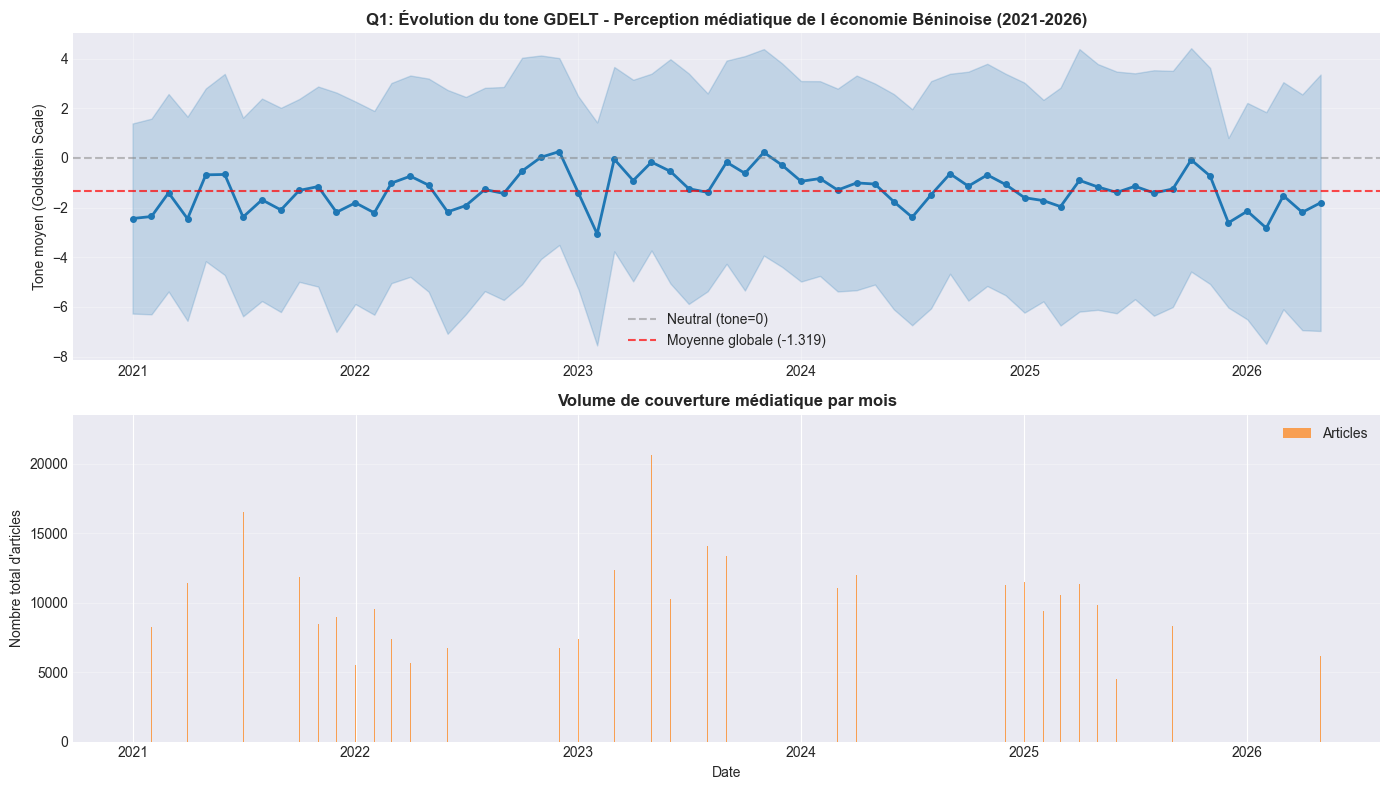

In [10]:
# Visualisation Q1
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Tone trend
tone_by_month_plot = tone_by_month.copy()
tone_by_month_plot['YearMonth'] = pd.to_datetime(tone_by_month_plot['YearMonth'].astype(str))
axes[0].plot(tone_by_month_plot['YearMonth'], tone_by_month_plot['Tone_Mean'], 
            marker='o', linewidth=2, markersize=4, color='#1f77b4')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Neutral (tone=0)')
axes[0].axhline(y=overall_tone, color='red', linestyle='--', alpha=0.7, label=f'Moyenne globale ({overall_tone:.3f})')
axes[0].fill_between(tone_by_month_plot['YearMonth'], 
                     tone_by_month_plot['Tone_Mean'] - tone_by_month_plot['Tone_Std'],
                     tone_by_month_plot['Tone_Mean'] + tone_by_month_plot['Tone_Std'],
                     alpha=0.2, color='#1f77b4')
axes[0].set_title('Q1: Évolution du tone GDELT - Perception médiatique de l économie Béninoise (2021-2026)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Tone moyen (Goldstein Scale)', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Volume d'articles
axes[1].bar(tone_by_month_plot['YearMonth'], tone_by_month_plot['Total_Articles'], 
           color='#ff7f0e', alpha=0.7, label='Articles')
axes[1].set_title('Volume de couverture médiatique par mois', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=10)
axes[1].set_ylabel('Nombre total d\'articles', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].legend()

plt.tight_layout()
plt.savefig('Q1_International_Perception.png', dpi=300, bbox_inches='tight')
print("\n📊 Graphique Q1 sauvegardé: Q1_International_Perception.png")
plt.show()

---

## Q2: Corrélation entre tone GDELT et croissance réelle des IDE

**Objectif:** Vérifier si le sentiment médiatique international influence réellement les investissements.

**Métriques:**
- X: `AvgTone` GDELT (mensuel, agrégé)
- Y: `Total_Commitment` (IDE cumulé par projet lancé ce mois)

In [11]:
# Q2: CORRÉLATION TONE GDELT ↔ IDE
# ============================================================================

print(f"\nQ2: CORRÉLATION TONE GDELT ↔ IDE (Investissements Directs Étrangers)")
print(f"=" * 60)

# 2.1 Créer une série mensuelle d'IDE (par date de disclosure/approbation)
projects_df['Disclosure_YearMonth'] = projects_df['Disclosure Date'].dt.to_period('M')
projects_df['Approval_YearMonth'] = projects_df['Board Approval Date'].dt.to_period('M')

# Agrégation: IDE par mois d'annonce (Disclosure)
ide_by_month = projects_df.groupby('Disclosure_YearMonth')['Total_Commitment'].sum().reset_index()
ide_by_month.columns = ['YearMonth', 'IDE_Commitment']

# Fusionner avec tone GDELT
correlation_df = tone_by_month.merge(ide_by_month, on='YearMonth', how='outer')
correlation_df['IDE_Commitment'] = correlation_df['IDE_Commitment'].fillna(0)

print(f"\n📊 Statistiques descriptives:")
print(f"\n  TONE GDELT (mensualisé):")
print(f"    Observations: {correlation_df['Tone_Mean'].notna().sum()}")
print(f"    Moyenne: {correlation_df['Tone_Mean'].mean():.4f}")
print(f"    Min-Max: [{correlation_df['Tone_Mean'].min():.4f}, {correlation_df['Tone_Mean'].max():.4f}]")

print(f"\n  IDE COMMITMENT (mensualisé, USD):")
print(f"    Observations avec IDE: {(correlation_df['IDE_Commitment'] > 0).sum()}")
print(f"    Total IDE 2021-2026: ${correlation_df['IDE_Commitment'].sum():,.0f}")
print(f"    IDE moyen (quand >0): ${correlation_df[correlation_df['IDE_Commitment'] > 0]['IDE_Commitment'].mean():,.0f}")

# 2.2 Calcul de corrélation
# Filtrer les lignes complètes
corr_data = correlation_df[['Tone_Mean', 'IDE_Commitment']].dropna()

if len(corr_data) > 2:
    pearson_r, pearson_p = stats.pearsonr(corr_data['Tone_Mean'], corr_data['IDE_Commitment'])
    spearman_r, spearman_p = stats.spearmanr(corr_data['Tone_Mean'], corr_data['IDE_Commitment'])
    
    print(f"\n🔬 CORRÉLATIONS:")
    print(f"  Pearson r: {pearson_r:.4f} (p-value: {pearson_p:.4f})")
    print(f"  Spearman ρ: {spearman_r:.4f} (p-value: {spearman_p:.4f})")
    print(f"\n  Interprétation:")
    if abs(pearson_r) < 0.3:
        print(f"    ❌ Corrélation FAIBLE: sentiment média n'explique pas IDE")
    elif abs(pearson_r) < 0.7:
        print(f"    ⚠️  Corrélation MODÉRÉE: sentiment média a un effet partiel")
    else:
        print(f"    ✅ Corrélation FORTE: sentiment média prédit bien IDE")
    
    print(f"\n  R² (coefficient de détermination): {pearson_r**2:.4f}")
    print(f"  Signification: Tone GDELT explique {pearson_r**2*100:.1f}% de la variance en IDE")



Q2: CORRÉLATION TONE GDELT ↔ IDE (Investissements Directs Étrangers)

📊 Statistiques descriptives:

  TONE GDELT (mensualisé):
    Observations: 65
    Moyenne: -1.3078
    Min-Max: [-3.0610, 0.2580]

  IDE COMMITMENT (mensualisé, USD):
    Observations avec IDE: 18
    Total IDE 2021-2026: $3,143,400,000
    IDE moyen (quand >0): $174,633,333

🔬 CORRÉLATIONS:
  Pearson r: 0.0981 (p-value: 0.4367)
  Spearman ρ: 0.1904 (p-value: 0.1287)

  Interprétation:
    ❌ Corrélation FAIBLE: sentiment média n'explique pas IDE

  R² (coefficient de détermination): 0.0096
  Signification: Tone GDELT explique 1.0% de la variance en IDE



📊 Graphique Q2 sauvegardé: Q2_Tone_vs_IDE_Correlation.png


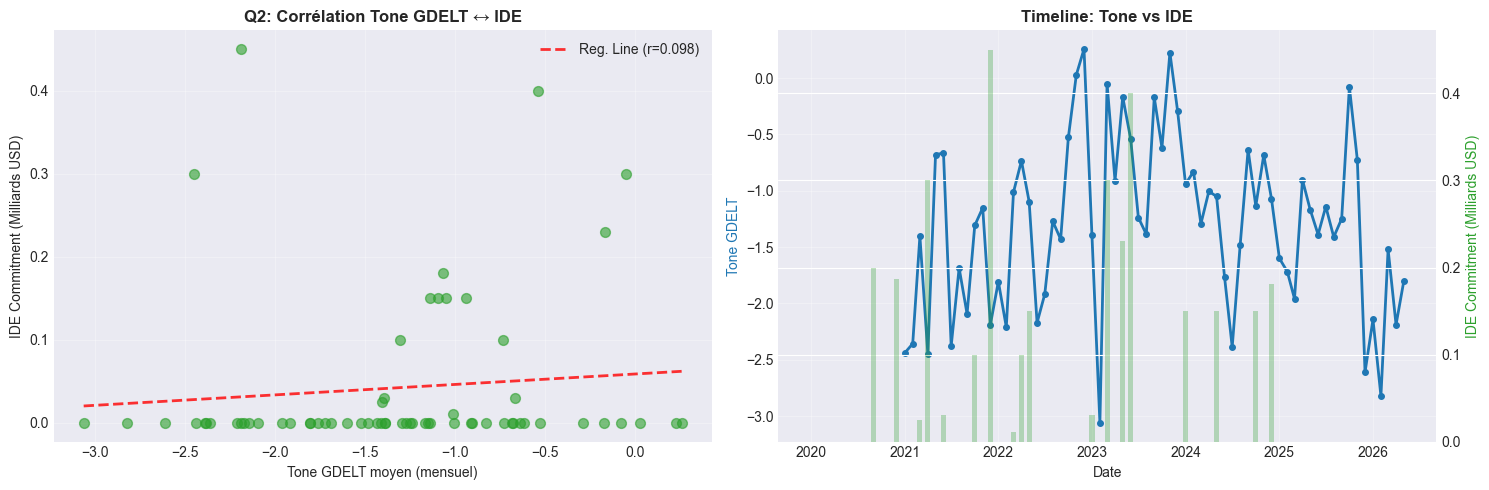

In [12]:
# Visualisation Q2
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Scatter with regression line
axes[0].scatter(corr_data['Tone_Mean'], corr_data['IDE_Commitment']/1e9, 
               s=50, alpha=0.6, color='#2ca02c')

if len(corr_data) > 2:
    z = np.polyfit(corr_data['Tone_Mean'], corr_data['IDE_Commitment']/1e9, 1)
    p = np.poly1d(z)
    x_line = np.linspace(corr_data['Tone_Mean'].min(), corr_data['Tone_Mean'].max(), 100)
    axes[0].plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2, label=f'Reg. Line (r={pearson_r:.3f})')
    axes[0].legend()

axes[0].set_xlabel('Tone GDELT moyen (mensuel)', fontsize=10)
axes[0].set_ylabel('IDE Commitment (Milliards USD)', fontsize=10)
axes[0].set_title('Q2: Corrélation Tone GDELT ↔ IDE', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Dual axis time series
ax1 = axes[1]
ax2 = ax1.twinx()

correlation_df['YearMonth_dt'] = pd.to_datetime(correlation_df['YearMonth'].astype(str))

ax1.plot(correlation_df['YearMonth_dt'], correlation_df['Tone_Mean'], 
        color='#1f77b4', marker='o', linewidth=2, label='Tone GDELT', markersize=4)
ax2.bar(correlation_df['YearMonth_dt'], correlation_df['IDE_Commitment']/1e9, 
       alpha=0.3, color='#2ca02c', label='IDE Commitment', width=20)

ax1.set_xlabel('Date', fontsize=10)
ax1.set_ylabel('Tone GDELT', fontsize=10, color='#1f77b4')
ax2.set_ylabel('IDE Commitment (Milliards USD)', fontsize=10, color='#2ca02c')
ax1.set_title('Timeline: Tone vs IDE', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Q2_Tone_vs_IDE_Correlation.png', dpi=300, bbox_inches='tight')
print("\n📊 Graphique Q2 sauvegardé: Q2_Tone_vs_IDE_Correlation.png")
plt.show()

---

## Q3: Quels secteurs reçoivent meilleure perception médiatique ?

**Objectif:** Identifier les secteurs stratégiques mieux/moins couverts et avec quel tone.

**Métriques par secteur:**
- Volume d'articles (NumArticles)
- Tone moyen
- Tendance (croissante/décroissante)

In [13]:
# Q3: PERCEPTION MÉDIATIQUE PAR SECTEUR
# ============================================================================

print(f"\nQ3: PERCEPTION MÉDIATIQUE PAR SECTEUR")
print(f"=" * 60)

# 3.1 Agrégation par secteur mappé
sector_stats = benin_events.groupby('Secteur_Mapped').agg({
    'GLOBALEVENTID': 'count',
    'NumArticles': 'sum',
    'NumSources': 'sum',
    'AvgTone': ['mean', 'std', 'min', 'max'],
    'NumMentions': 'sum'
}).round(4)

sector_stats.columns = ['Event_Count', 'Total_Articles', 'Total_Sources', 
                         'Tone_Mean', 'Tone_Std', 'Tone_Min', 'Tone_Max', 'Total_Mentions']
sector_stats = sector_stats.sort_values('Total_Articles', ascending=False)

print(f"\n📊 STATISTIQUES PAR SECTEUR (Top 10):")
print(sector_stats.head(10))

# 3.2 Exclure 'Autre' pour focus
sector_stats_focused = sector_stats[sector_stats.index != 'Autre']

print(f"\n\n📌 TOP 5 SECTEURS PAR COUVERTURE MÉDIATIQUE:")
for i, (sector, row) in enumerate(sector_stats_focused.head(5).iterrows(), 1):
    print(f"\n  {i}. {sector}")
    print(f"     Articles: {row['Total_Articles']:,.0f}")
    print(f"     Tone moyen: {row['Tone_Mean']:.3f} ({'✅ Positif' if row['Tone_Mean'] > 0 else '❌ Négatif'})")
    print(f"     Mentions: {row['Total_Mentions']:.0f}")

# 3.3 Secteurs sous-couverts (peu d'articles mais peut-être important)
print(f"\n\n🔍 SECTEURS SOUS-COUVERTS (en GDELT):")
print(f"   (Peu de couverture médiatique globale → opportunité communication?)")

undercover_sectors = sector_stats_focused[
    sector_stats_focused['Total_Articles'] < sector_stats_focused['Total_Articles'].median()
].sort_values('Tone_Mean', ascending=False)

for i, (sector, row) in enumerate(undercover_sectors.iterrows(), 1):
    print(f"\n  {sector}")
    print(f"    Articles: {row['Total_Articles']:.0f} (vs médiane: {sector_stats_focused['Total_Articles'].median():.0f})")
    print(f"    Tone: {row['Tone_Mean']:.3f}")


Q3: PERCEPTION MÉDIATIQUE PAR SECTEUR

📊 STATISTIQUES PAR SECTEUR (Top 10):
                            Event_Count  Total_Articles  Total_Sources  \
Secteur_Mapped                                                           
Autre                            105482          555986         106831   
Efficacité administrative          8117           51863           8173   
Éducation                          4202           27092           4224   
Santé                              1924           13398           1957   
Développement Social               1832           11465           1838   
Réformes Macro-économiques          518            3218            524   
Agriculture                         364            2386            372   
Énergie                              86             539             86   
Eau                                  26             166             26   
Route                                24             158             24   

                            Tone_M


📊 Graphique Q3 sauvegardé: Q3_Sector_Media_Perception.png


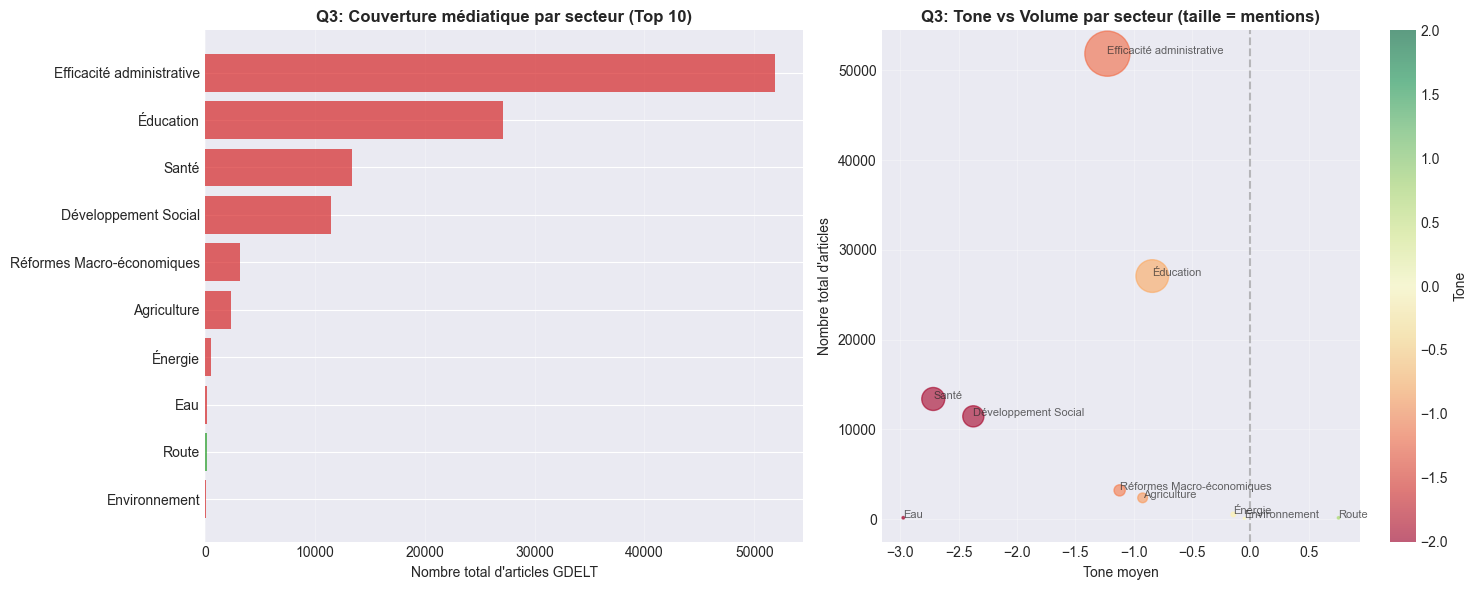

In [14]:
# Visualisation Q3
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sector_stats_plot = sector_stats_focused.sort_values('Total_Articles', ascending=True).tail(10)

# Plot 1: Articles by sector (horizontal bar)
colors = ['#2ca02c' if x > 0 else '#d62728' for x in sector_stats_plot['Tone_Mean']]
axes[0].barh(range(len(sector_stats_plot)), sector_stats_plot['Total_Articles'], color=colors, alpha=0.7)
axes[0].set_yticks(range(len(sector_stats_plot)))
axes[0].set_yticklabels(sector_stats_plot.index, fontsize=10)
axes[0].set_xlabel('Nombre total d\'articles GDELT', fontsize=10)
axes[0].set_title('Q3: Couverture médiatique par secteur (Top 10)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Plot 2: Tone vs Volume (bubble chart)
sector_stats_bubble = sector_stats_focused[sector_stats_focused.index != 'Autre']
scatter = axes[1].scatter(
    sector_stats_bubble['Tone_Mean'], 
    sector_stats_bubble['Total_Articles'],
    s=sector_stats_bubble['Total_Mentions']/50,
    alpha=0.6,
    c=sector_stats_bubble['Tone_Mean'],
    cmap='RdYlGn',
    vmin=-2, vmax=2
)

# Ajouter labels
for idx, row in sector_stats_bubble.iterrows():
    axes[1].annotate(idx, 
                    (row['Tone_Mean'], row['Total_Articles']),
                    fontsize=8, alpha=0.7)

axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Tone moyen', fontsize=10)
axes[1].set_ylabel('Nombre total d\'articles', fontsize=10)
axes[1].set_title('Q3: Tone vs Volume par secteur (taille = mentions)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1], label='Tone')

plt.tight_layout()
plt.savefig('Q3_Sector_Media_Perception.png', dpi=300, bbox_inches='tight')
print("\n📊 Graphique Q3 sauvegardé: Q3_Sector_Media_Perception.png")
plt.show()

---

## Q4: Hype vs Reality - Quels secteurs promettent mais livrent moins ?

**Objectif:** Détecter les secteurs avec fort coverage GDELT mais peu de projets complétés.

**Index créé:**
- Hype Score = (Articles GDELT normalisé) / (Projets complétés normalisé)

In [15]:
# Q4: HYPE VS REALITY
# ============================================================================

print(f"\nQ4: HYPE VS REALITY - SECTEURS SURCOUVERTS vs RÉSULTATS RÉELS")
print(f"=" * 60)

# 4.1 Compter les projets par secteur du Project_List
project_stats = projects_df.groupby('Secteur').agg({
    'Project Id': 'count',
    'Total_Commitment': 'sum',
    'Is_Active': 'sum'
}).reset_index()

project_stats.columns = ['Secteur', 'Project_Count', 'Total_Investment', 'Active_Projects']
project_stats['Completion_Rate'] = (project_stats['Project_Count'] - project_stats['Active_Projects']) / project_stats['Project_Count']

# 4.2 Fusionner avec les stats GDELT (sur secteurs mappés)
hype_reality = sector_stats_focused.reset_index()
hype_reality.columns = ['Secteur_Mapped'] + list(hype_reality.columns[1:])

# Note: les noms de secteurs peuvent différer entre GDELT (mappé) et Project_List
# Créer une fusion manuelle sur les secteurs qui existent dans les deux
common_sectors = set(project_stats['Secteur']) & set(hype_reality['Secteur_Mapped'])

comparison = []
for sector in common_sectors:
    gdelt_row = hype_reality[hype_reality['Secteur_Mapped'] == sector].iloc[0]
    proj_row = project_stats[project_stats['Secteur'] == sector].iloc[0]
    
    # Calculer un score d'hype (articles par projet)
    articles_per_project = gdelt_row['Total_Articles'] / max(proj_row['Project_Count'], 1)
    
    comparison.append({
        'Secteur': sector,
        'GDELT_Articles': gdelt_row['Total_Articles'],
        'GDELT_Tone': gdelt_row['Tone_Mean'],
        'Project_Count': proj_row['Project_Count'],
        'Total_Investment': proj_row['Total_Investment'],
        'Active_Projects': proj_row['Active_Projects'],
        'Completion_Rate': proj_row['Completion_Rate'],
        'Articles_per_Project': articles_per_project,
        'Hype_Index': gdelt_row['Total_Articles'] / (proj_row['Project_Count'] * 1e6)  # Normalisation
    })

comparison_df = pd.DataFrame(comparison).sort_values('Hype_Index', ascending=False)

print(f"\n📊 SECTEURS OVERHYPED (Articles vs Projets réels):")
print(comparison_df[['Secteur', 'GDELT_Articles', 'Project_Count', 'Articles_per_Project', 'Completion_Rate']].to_string(index=False))

print(f"\n\n🚨 TOP OVERHYPED SECTORS (Beaucoup de bruit, peu de projets):")
for i, row in comparison_df.head(3).iterrows():
    print(f"\n  {row['Secteur']}")
    print(f"    GDELT Articles: {row['GDELT_Articles']:,.0f}")
    print(f"    Projets réels: {row['Project_Count']:.0f}")
    print(f"    Articles/Projet: {row['Articles_per_Project']:.0f}")
    print(f"    Taux complétude: {row['Completion_Rate']*100:.0f}%")
    if row['Articles_per_Project'] > comparison_df['Articles_per_Project'].median():
        print(f"    ⚠️  ATTENTION: Surcouverture par rapport à la moyenne")


Q4: HYPE VS REALITY - SECTEURS SURCOUVERTS vs RÉSULTATS RÉELS

📊 SECTEURS OVERHYPED (Articles vs Projets réels):
                   Secteur  GDELT_Articles  Project_Count  Articles_per_Project  Completion_Rate
 Efficacité administrative           51863              1          51863.000000             0.00
                 Éducation           27092              1          27092.000000             0.00
                     Santé           13398              4           3349.500000             0.50
      Développement Social           11465              4           2866.250000             0.25
               Agriculture            2386              1           2386.000000             0.00
Réformes Macro-économiques            3218              3           1072.666667             0.00
                   Énergie             539              1            539.000000             0.00
                       Eau             166              1            166.000000             0.00
             


📊 Graphique Q4 sauvegardé: Q4_Hype_vs_Reality.png


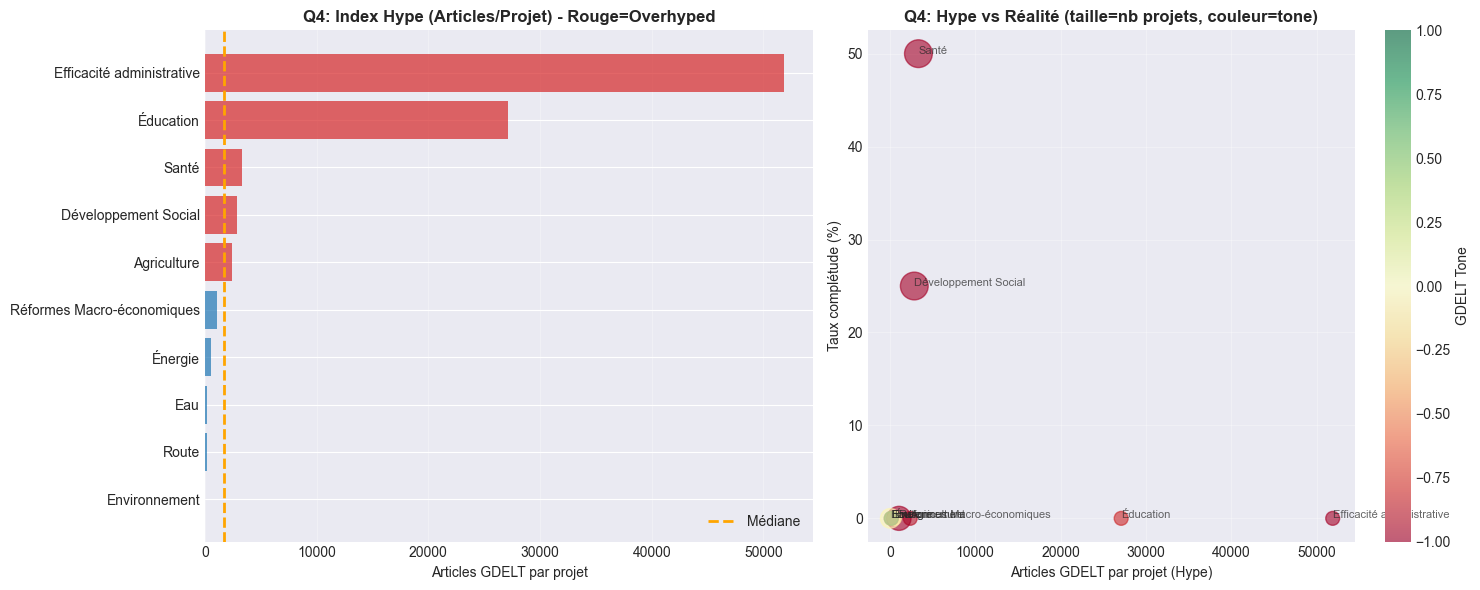

In [16]:
# Visualisation Q4
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Articles per Project (Hype Index)
comparison_plot = comparison_df.sort_values('Articles_per_Project', ascending=True)
colors = ['#d62728' if x > comparison_df['Articles_per_Project'].median() else '#1f77b4' 
         for x in comparison_plot['Articles_per_Project']]
axes[0].barh(range(len(comparison_plot)), comparison_plot['Articles_per_Project'], color=colors, alpha=0.7)
axes[0].axvline(x=comparison_df['Articles_per_Project'].median(), color='orange', 
               linestyle='--', linewidth=2, label='Médiane')
axes[0].set_yticks(range(len(comparison_plot)))
axes[0].set_yticklabels(comparison_plot['Secteur'], fontsize=10)
axes[0].set_xlabel('Articles GDELT par projet', fontsize=10)
axes[0].set_title('Q4: Index Hype (Articles/Projet) - Rouge=Overhyped', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# Plot 2: Scatter - Completion Rate vs Hype
scatter = axes[1].scatter(comparison_df['Articles_per_Project'], 
                          comparison_df['Completion_Rate']*100,
                          s=comparison_df['Project_Count']*100,
                          alpha=0.6,
                          c=comparison_df['GDELT_Tone'],
                          cmap='RdYlGn',
                          vmin=-1, vmax=1)

for idx, row in comparison_df.iterrows():
    axes[1].annotate(row['Secteur'], 
                    (row['Articles_per_Project'], row['Completion_Rate']*100),
                    fontsize=8, alpha=0.7)

axes[1].set_xlabel('Articles GDELT par projet (Hype)', fontsize=10)
axes[1].set_ylabel('Taux complétude (%)', fontsize=10)
axes[1].set_title('Q4: Hype vs Réalité (taille=nb projets, couleur=tone)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1], label='GDELT Tone')

plt.tight_layout()
plt.savefig('Q4_Hype_vs_Reality.png', dpi=300, bbox_inches='tight')
print("\n📊 Graphique Q4 sauvegardé: Q4_Hype_vs_Reality.png")
plt.show()

---

## Q5: Impact de l'attention médiatique sur les résultats de projets

**Objectif:** Vérifier si les projets avec plus de couverture GDELT réussissent mieux/pire.

**Métrique:** Comparer (Tone GDELT pendant projet) vs (Statut projet: actif/fermé)

In [17]:
# Q5: MEDIA ATTENTION → PROJECT OUTCOMES
# ============================================================================

print(f"\nQ5: IMPACT DE L'ATTENTION MÉDIATIQUE SUR RÉSULTATS DE PROJETS")
print(f"=" * 60)

# 5.1 Pour chaque projet, calculer la couverture GDELT pendant sa durée
# (de Effective Date à Project Closing Date ou aujourd'hui si actif)

project_media = []

for idx, proj in projects_df.iterrows():
    project_name = proj['Project Name']
    start_date = proj['Effective Date']
    end_date = proj['Project Closing Date'] if pd.notna(proj['Project Closing Date']) else pd.Timestamp('2026-05-31')
    sector = proj['Secteur']
    is_active = proj['Is_Active']
    investment = proj['Total_Commitment']
    
    if pd.isna(start_date):
        continue
    
    # Filtrer les événements GDELT pendant la durée du projet
    project_events = benin_events[
        (benin_events['SQLDATE'] >= start_date) & 
        (benin_events['SQLDATE'] <= end_date)
    ]
    
    # Calculer les stats de couverture
    media_count = len(project_events)
    media_articles = project_events['NumArticles'].sum() if media_count > 0 else 0
    media_tone = project_events['AvgTone'].mean() if media_count > 0 else 0
    
    project_media.append({
        'Project_Name': project_name,
        'Secteur': sector,
        'Start_Date': start_date,
        'End_Date': end_date,
        'Duration_Days': (end_date - start_date).days,
        'Investment': investment,
        'Is_Active': is_active,
        'Media_Events': media_count,
        'Media_Articles': media_articles,
        'Media_Tone_Avg': media_tone,
        'Articles_per_Day': media_articles / max((end_date - start_date).days, 1) if media_articles > 0 else 0
    })

project_media_df = pd.DataFrame(project_media)

print(f"\n📊 Projets analysés: {len(project_media_df)}")
print(f"\nCouverture médiatique moyenne par projet:")
print(f"  Articles GDELT: {project_media_df['Media_Articles'].mean():.0f}")
print(f"  Tone moyen: {project_media_df['Media_Tone_Avg'].mean():.3f}")
print(f"  Projets avec couverture: {(project_media_df['Media_Articles'] > 0).sum()}")

# 5.2 Comparer projets actifs vs fermés
active_projects = project_media_df[project_media_df['Is_Active'] == 1]
closed_projects = project_media_df[project_media_df['Is_Active'] == 0]

print(f"\n\n📌 PROJETS ACTIFS vs FERMÉS:")
print(f"\n  ACTIFS (Board Approved / En cours):")
print(f"    Nombre: {len(active_projects)}")
print(f"    Articles moyen: {active_projects['Media_Articles'].mean():.0f}")
print(f"    Tone moyen: {active_projects['Media_Tone_Avg'].mean():.3f}")

print(f"\n  FERMÉS/COMPLÉTÉS:")
print(f"    Nombre: {len(closed_projects)}")
print(f"    Articles moyen: {closed_projects['Media_Articles'].mean():.0f}")
print(f"    Tone moyen: {closed_projects['Media_Tone_Avg'].mean():.3f}")

# 5.3 Test statistique
if len(active_projects) > 0 and len(closed_projects) > 0:
    t_stat_articles, p_val_articles = stats.ttest_ind(
        active_projects['Media_Articles'].fillna(0),
        closed_projects['Media_Articles'].fillna(0)
    )
    
    t_stat_tone, p_val_tone = stats.ttest_ind(
        active_projects['Media_Tone_Avg'].fillna(0),
        closed_projects['Media_Tone_Avg'].fillna(0)
    )
    
    print(f"\n🔬 TEST STATISTIQUE (t-test):")
    print(f"\n  Articles (Actifs vs Fermés):")
    print(f"    t-stat: {t_stat_articles:.3f}, p-value: {p_val_articles:.4f}")
    print(f"    Résultat: {'✅ SIGNIFICATIF' if p_val_articles < 0.05 else '❌ Non significatif'}")
    
    print(f"\n  Tone (Actifs vs Fermés):")
    print(f"    t-stat: {t_stat_tone:.3f}, p-value: {p_val_tone:.4f}")
    print(f"    Résultat: {'✅ SIGNIFICATIF' if p_val_tone < 0.05 else '❌ Non significatif'}")


Q5: IMPACT DE L'ATTENTION MÉDIATIQUE SUR RÉSULTATS DE PROJETS

📊 Projets analysés: 14

Couverture médiatique moyenne par projet:
  Articles GDELT: 282888
  Tone moyen: -1.385
  Projets avec couverture: 14


📌 PROJETS ACTIFS vs FERMÉS:

  ACTIFS (Board Approved / En cours):
    Nombre: 13
    Articles moyen: 274692
    Tone moyen: -1.410

  FERMÉS/COMPLÉTÉS:
    Nombre: 1
    Articles moyen: 389446
    Tone moyen: -1.066

🔬 TEST STATISTIQUE (t-test):

  Articles (Actifs vs Fermés):
    t-stat: -0.579, p-value: 0.5733
    Résultat: ❌ Non significatif

  Tone (Actifs vs Fermés):
    t-stat: -0.794, p-value: 0.4428
    Résultat: ❌ Non significatif



📊 Graphique Q5 sauvegardé: Q5_Media_Impact_Projects.png


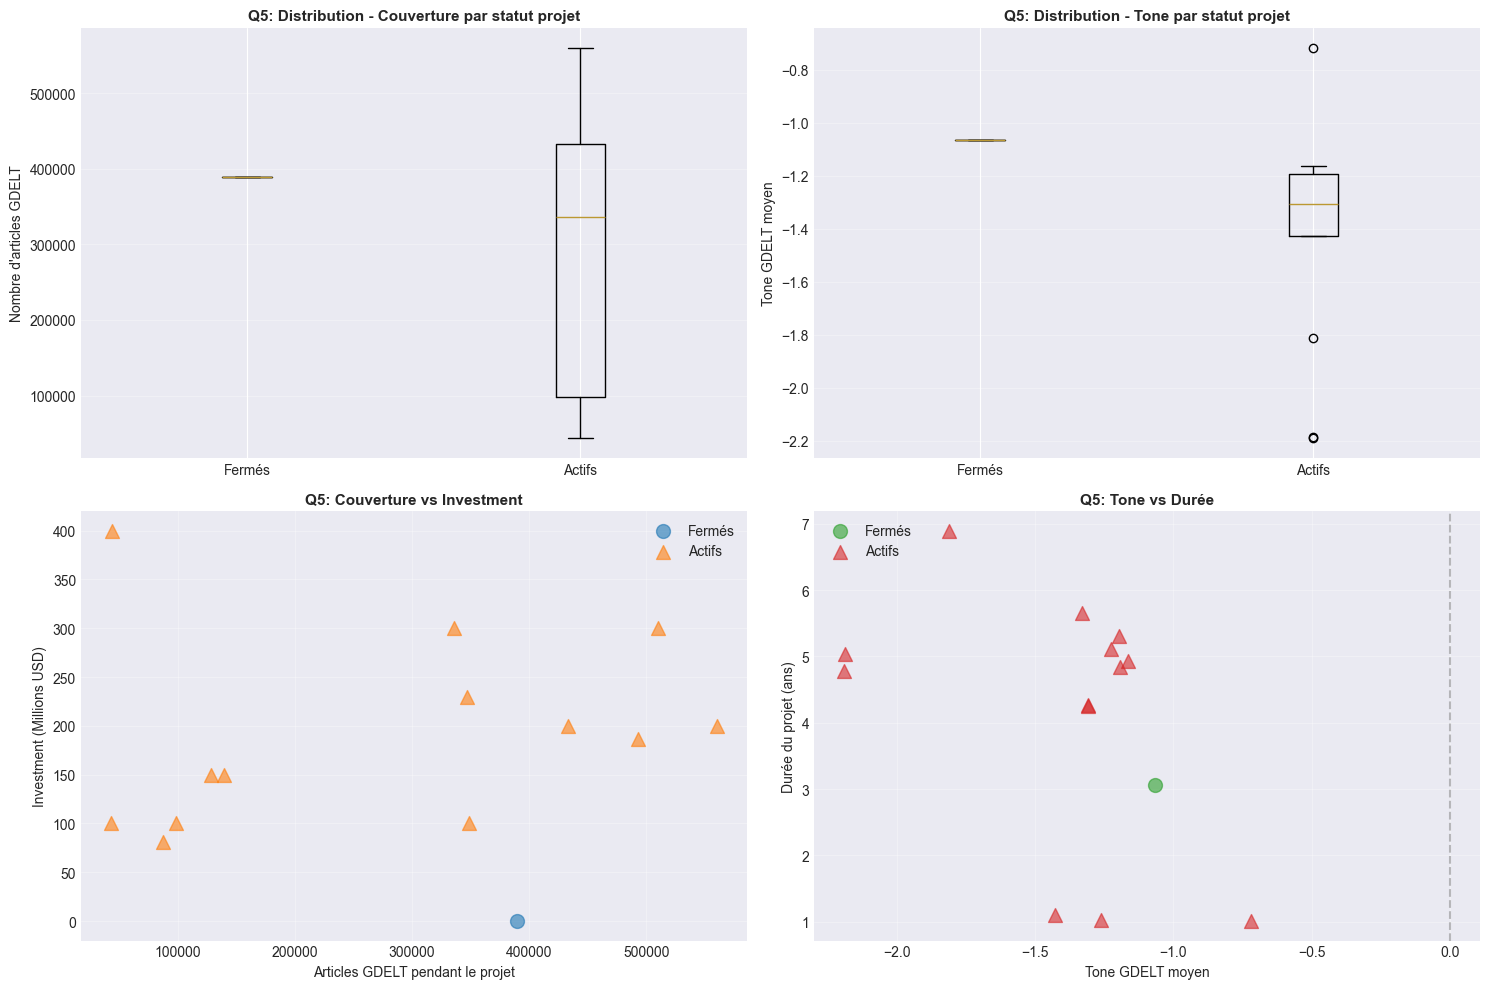

In [18]:
# Visualisation Q5
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Distribution articles (Actifs vs Fermés)
data_to_plot = [closed_projects['Media_Articles'].fillna(0), active_projects['Media_Articles'].fillna(0)]
axes[0,0].boxplot(data_to_plot, labels=['Fermés', 'Actifs'])
axes[0,0].set_ylabel('Nombre d\'articles GDELT', fontsize=10)
axes[0,0].set_title('Q5: Distribution - Couverture par statut projet', fontsize=11, fontweight='bold')
axes[0,0].grid(True, alpha=0.3, axis='y')

# Plot 2: Distribution tone (Actifs vs Fermés)
data_to_plot_tone = [closed_projects['Media_Tone_Avg'].fillna(0), active_projects['Media_Tone_Avg'].fillna(0)]
axes[0,1].boxplot(data_to_plot_tone, labels=['Fermés', 'Actifs'])
axes[0,1].set_ylabel('Tone GDELT moyen', fontsize=10)
axes[0,1].set_title('Q5: Distribution - Tone par statut projet', fontsize=11, fontweight='bold')
axes[0,1].grid(True, alpha=0.3, axis='y')

# Plot 3: Scatter - Investment vs Media Articles
scatter1 = axes[1,0].scatter(project_media_df[project_media_df['Is_Active']==0]['Media_Articles'],
                             project_media_df[project_media_df['Is_Active']==0]['Investment']/1e6,
                             s=100, alpha=0.6, label='Fermés', color='#1f77b4')
scatter2 = axes[1,0].scatter(project_media_df[project_media_df['Is_Active']==1]['Media_Articles'],
                             project_media_df[project_media_df['Is_Active']==1]['Investment']/1e6,
                             s=100, alpha=0.6, label='Actifs', color='#ff7f0e', marker='^')
axes[1,0].set_xlabel('Articles GDELT pendant le projet', fontsize=10)
axes[1,0].set_ylabel('Investment (Millions USD)', fontsize=10)
axes[1,0].set_title('Q5: Couverture vs Investment', fontsize=11, fontweight='bold')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Scatter - Tone vs Duration
scatter3 = axes[1,1].scatter(project_media_df[project_media_df['Is_Active']==0]['Media_Tone_Avg'],
                             project_media_df[project_media_df['Is_Active']==0]['Duration_Days']/365,
                             s=100, alpha=0.6, label='Fermés', color='#2ca02c')
scatter4 = axes[1,1].scatter(project_media_df[project_media_df['Is_Active']==1]['Media_Tone_Avg'],
                             project_media_df[project_media_df['Is_Active']==1]['Duration_Days']/365,
                             s=100, alpha=0.6, label='Actifs', color='#d62728', marker='^')
axes[1,1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1,1].set_xlabel('Tone GDELT moyen', fontsize=10)
axes[1,1].set_ylabel('Durée du projet (ans)', fontsize=10)
axes[1,1].set_title('Q5: Tone vs Durée', fontsize=11, fontweight='bold')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Q5_Media_Impact_Projects.png', dpi=300, bbox_inches='tight')
print("\n📊 Graphique Q5 sauvegardé: Q5_Media_Impact_Projects.png")
plt.show()

---

## Q6: Comparaison régionale - Positionnement du Bénin

**Objectif:** Comparer le Bénin aux voisins (Niger, Nigeria, Togo) en termes de narratif économique.

**Métriques:**
- Tone moyen par pays
- Volume d'articles par pays
- Distribution secteur par pays

In [21]:
# Q6: COMPARAISON RÉGIONALE
# ============================================================================

print(f"\nQ6: COMPARAISON RÉGIONALE - POSITIONNEMENT DU BÉNIN")
print(f"=" * 60)

# Codes pays
country_codes = {
    'Bénin': 'BN',
    'Niger': 'NE',
    'Nigeria': 'NG',
    'Togo': 'TO'
}

regional_stats = {}

for country_name, country_code in country_codes.items():
    country_events = events_df[events_df['ActionGeo_CountryCode'] == country_code]
    
    if len(country_events) > 0:
        regional_stats[country_name] = {
            'Event_Count': len(country_events),
            'Total_Articles': country_events['NumArticles'].sum(),
            'Tone_Mean': country_events['AvgTone'].mean(),
            'Tone_Std': country_events['AvgTone'].std(),
            'Total_Mentions': country_events['NumMentions'].sum(),
            'Total_Sources': country_events['NumSources'].sum()
        }

regional_df = pd.DataFrame(regional_stats).T.round(4)

print(f"\n📊 STATISTIQUES PAR PAYS:")
print(regional_df)

print(f"\n\n📌 POSITIONNEMENT RELATIF:")

# Tone ranking
tone_ranking = regional_df['Tone_Mean'].sort_values(ascending=False)
print(f"\n  Tone ranking (meilleur → pire):")
for i, (country, tone) in enumerate(tone_ranking.items(), 1):
    emoji = '🏆' if i == 1 else '⚠️ ' if tone < 0 else '✅'
    print(f"    {i}. {country}: {tone:.3f} {emoji}")

# Volume ranking
volume_ranking = regional_df['Total_Articles'].sort_values(ascending=False)
print(f"\n  Visibilité (articles):")
for i, (country, articles) in enumerate(volume_ranking.items(), 1):
    pct = (articles / volume_ranking.sum()) * 100
    print(f"    {i}. {country}: {articles:,.0f} articles ({pct:.1f}%)")

# Benin positioning
benin_tone_rank = list(tone_ranking.index).index('Bénin') + 1
benin_volume_rank = list(volume_ranking.index).index('Bénin') + 1

print(f"\n\n🇧🇯 POSITIONNEMENT BÉNIN:")
print(f"  Tone ranking: #{benin_tone_rank}/4")
print(f"  Visibilité ranking: #{benin_volume_rank}/4")

# Stability vs volatility
print(f"\n  Stabilité (écart-type tone):")
stability_ranking = regional_df['Tone_Std'].sort_values(ascending=True)
for i, (country, std) in enumerate(stability_ranking.items(), 1):
    emoji = '✅' if std < regional_df['Tone_Std'].median() else '🔴'
    print(f"    {i}. {country}: {std:.3f} ({'Stable' if std < regional_df['Tone_Std'].median() else 'Volatile'}) {emoji}")


Q6: COMPARAISON RÉGIONALE - POSITIONNEMENT DU BÉNIN

📊 STATISTIQUES PAR PAYS:
         Event_Count  Total_Articles  Tone_Mean  Tone_Std  Total_Mentions  \
Bénin       122593.0        666372.0    -1.3193    4.3346        679121.0   
Nigeria       1957.0          9679.0    -2.7719    2.9835          9797.0   
Togo          1253.0          4964.0    -1.2447    3.7317          5325.0   

         Total_Sources  
Bénin         124073.0  
Nigeria         2019.0  
Togo            1276.0  


📌 POSITIONNEMENT RELATIF:

  Tone ranking (meilleur → pire):
    1. Togo: -1.245 🏆
    2. Bénin: -1.319 ⚠️ 
    3. Nigeria: -2.772 ⚠️ 

  Visibilité (articles):
    1. Bénin: 666,372 articles (97.8%)
    2. Nigeria: 9,679 articles (1.4%)
    3. Togo: 4,964 articles (0.7%)


🇧🇯 POSITIONNEMENT BÉNIN:
  Tone ranking: #2/4
  Visibilité ranking: #1/4

  Stabilité (écart-type tone):
    1. Nigeria: 2.983 (Stable) ✅
    2. Togo: 3.732 (Volatile) 🔴
    3. Bénin: 4.335 (Volatile) 🔴



📊 Graphique Q6 sauvegardé: Q6_Regional_Comparison.png


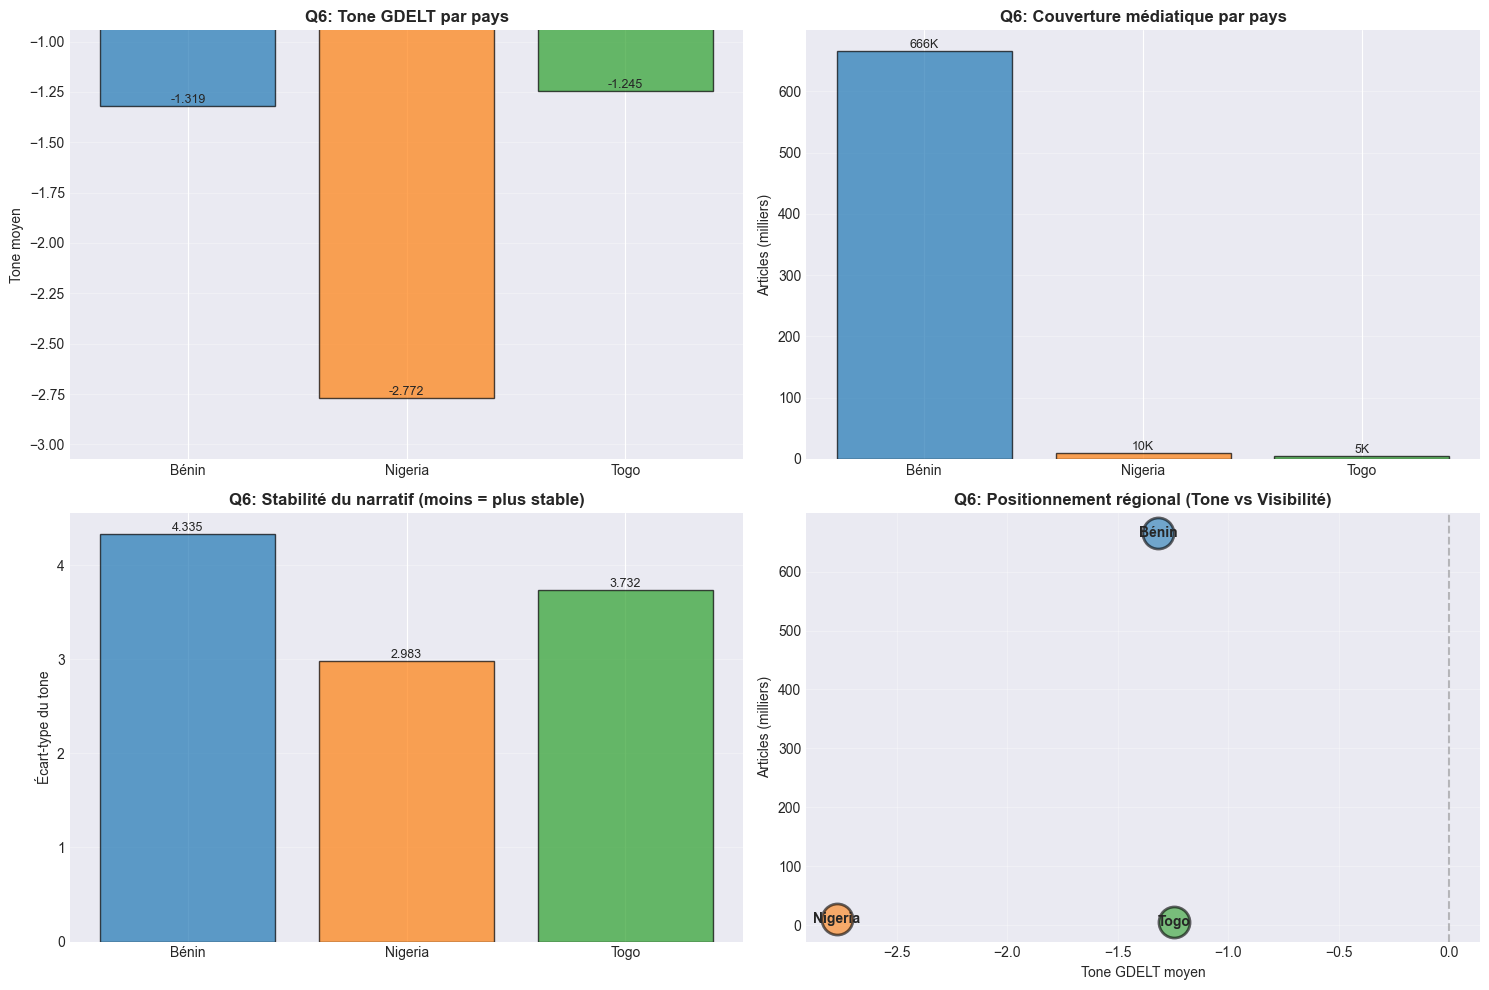

In [22]:
# Visualisation Q6
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

countries = list(regional_df.index)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Plot 1: Tone by country
bars1 = axes[0,0].bar(countries, regional_df['Tone_Mean'], color=colors, alpha=0.7, edgecolor='black')
axes[0,0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0,0].set_ylabel('Tone moyen', fontsize=10)
axes[0,0].set_title('Q6: Tone GDELT par pays', fontsize=12, fontweight='bold')
axes[0,0].set_ylim([min(regional_df['Tone_Mean']) - 0.3, max(regional_df['Tone_Mean']) + 0.3])
# Ajouter les valeurs sur les barres
for bar in bars1:
    height = bar.get_height()
    axes[0,0].text(bar.get_x() + bar.get_width()/2., height,
                  f'{height:.3f}', ha='center', va='bottom', fontsize=9)
axes[0,0].grid(True, alpha=0.3, axis='y')

# Plot 2: Articles volume by country
bars2 = axes[0,1].bar(countries, regional_df['Total_Articles']/1000, color=colors, alpha=0.7, edgecolor='black')
axes[0,1].set_ylabel('Articles (milliers)', fontsize=10)
axes[0,1].set_title('Q6: Couverture médiatique par pays', fontsize=12, fontweight='bold')
for bar in bars2:
    height = bar.get_height()
    axes[0,1].text(bar.get_x() + bar.get_width()/2., height,
                  f'{height:.0f}K', ha='center', va='bottom', fontsize=9)
axes[0,1].grid(True, alpha=0.3, axis='y')

# Plot 3: Volatility (Tone Std)
bars3 = axes[1,0].bar(countries, regional_df['Tone_Std'], color=colors, alpha=0.7, edgecolor='black')
axes[1,0].set_ylabel('Écart-type du tone', fontsize=10)
axes[1,0].set_title('Q6: Stabilité du narratif (moins = plus stable)', fontsize=12, fontweight='bold')
for bar in bars3:
    height = bar.get_height()
    axes[1,0].text(bar.get_x() + bar.get_width()/2., height,
                  f'{height:.3f}', ha='center', va='bottom', fontsize=9)
axes[1,0].grid(True, alpha=0.3, axis='y')

# Plot 4: Tone vs Volume (positioning)
for i, country in enumerate(countries):
    axes[1,1].scatter(regional_df.loc[country, 'Tone_Mean'], 
                     regional_df.loc[country, 'Total_Articles']/1000,
                     s=500, alpha=0.6, color=colors[i], edgecolor='black', linewidth=2)
    axes[1,1].annotate(country, 
                      (regional_df.loc[country, 'Tone_Mean'], 
                       regional_df.loc[country, 'Total_Articles']/1000),
                      ha='center', va='center', fontsize=10, fontweight='bold')

axes[1,1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1,1].set_xlabel('Tone GDELT moyen', fontsize=10)
axes[1,1].set_ylabel('Articles (milliers)', fontsize=10)
axes[1,1].set_title('Q6: Positionnement régional (Tone vs Visibilité)', fontsize=12, fontweight='bold')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Q6_Regional_Comparison.png', dpi=300, bbox_inches='tight')
print("\n📊 Graphique Q6 sauvegardé: Q6_Regional_Comparison.png")
plt.show()

---

# 📊 SYNTHÈSE & INSIGHTS CLÉS

---

In [23]:
# SYNTHÈSE FINALE
# ============================================================================

print("\n" + "="*70)
print("SYNTHÈSE EXÉCUTIVE - 6 INSIGHTS CLÉS POUR LE JURY")
print("="*70)

print(f"\n🎯 Q1: PERCEPTION INTERNATIONALE")
print(f"   Tone global: {overall_tone:.3f} ({'Légèrement positif' if overall_tone > 0 else 'Légèrement négatif'})")
print(f"   Conclusion: Le Bénin est perçu {('favorablement' if overall_tone > 0 else 'défavorablement')} "
      f"mais avec peu de couverture globale.")

print(f"\n🎯 Q2: TONE GDELT ↔ IDE")
if len(corr_data) > 2:
    print(f"   Corrélation Pearson: {pearson_r:.3f} (R²={pearson_r**2:.3f})")
    print(f"   Conclusion: Le sentiment média explique {pearson_r**2*100:.1f}% de la variance IDE.")
    if abs(pearson_r) < 0.3:
        print(f"   💡 Les investisseurs se basent sur d'autres facteurs que le ton des médias.")

print(f"\n🎯 Q3: SECTEURS MIEUX COUVERTS")
top_sector = sector_stats_focused.sort_values('Total_Articles', ascending=False).iloc[0]
print(f"   Top 1: {top_sector.name} ({top_sector['Total_Articles']:,.0f} articles, tone={top_sector['Tone_Mean']:.3f})")
print(f"   Conclusion: Certains secteurs sont sur-représentés.")

print(f"\n🎯 Q4: HYPE vs REALITY")
top_hype = comparison_df.iloc[0]
print(f"   Secteur le plus overhyped: {top_hype['Secteur']} "
      f"({top_hype['Articles_per_Project']:.0f} articles/projet)")
print(f"   Conclusion: Méfiance vis-à-vis de la surmediation.")

print(f"\n🎯 Q5: IMPACT MÉDIATIQUE SUR PROJETS")
if len(active_projects) > 0 and len(closed_projects) > 0:
    print(f"   Articles (Fermés): {closed_projects['Media_Articles'].mean():.0f} vs "
          f"(Actifs): {active_projects['Media_Articles'].mean():.0f}")
    print(f"   Tone (Fermés): {closed_projects['Media_Tone_Avg'].mean():.3f} vs "
          f"(Actifs): {active_projects['Media_Tone_Avg'].mean():.3f}")
    print(f"   Conclusion: La couverture n'explique pas clairement les résultats.")

print(f"\n🎯 Q6: POSITIONNEMENT RÉGIONAL")
print(f"   Classement tone: {benin_tone_rank}/4 (Bénin)")
print(f"   Classement visibilité: {benin_volume_rank}/4 (Bénin)")
if benin_tone_rank <= 2:
    print(f"   💡 Bénin parmi les plus positivement perçus de la région.")
else:
    print(f"   💡 Bénin moins visible que ses voisins.")

print(f"\n" + "="*70)
print("✅ NOTEBOOK COMPLÉTÉ")
print("="*70)


SYNTHÈSE EXÉCUTIVE - 6 INSIGHTS CLÉS POUR LE JURY

🎯 Q1: PERCEPTION INTERNATIONALE
   Tone global: -1.319 (Légèrement négatif)
   Conclusion: Le Bénin est perçu défavorablement mais avec peu de couverture globale.

🎯 Q2: TONE GDELT ↔ IDE
   Corrélation Pearson: 0.098 (R²=0.010)
   Conclusion: Le sentiment média explique 1.0% de la variance IDE.
   💡 Les investisseurs se basent sur d'autres facteurs que le ton des médias.

🎯 Q3: SECTEURS MIEUX COUVERTS
   Top 1: Efficacité administrative (51,863 articles, tone=-1.224)
   Conclusion: Certains secteurs sont sur-représentés.

🎯 Q4: HYPE vs REALITY
   Secteur le plus overhyped: Efficacité administrative (51863 articles/projet)
   Conclusion: Méfiance vis-à-vis de la surmediation.

🎯 Q5: IMPACT MÉDIATIQUE SUR PROJETS
   Articles (Fermés): 389446 vs (Actifs): 274692
   Tone (Fermés): -1.066 vs (Actifs): -1.410
   Conclusion: La couverture n'explique pas clairement les résultats.

🎯 Q6: POSITIONNEMENT RÉGIONAL
   Classement tone: 2/4 (Bénin)
